# Neuronal Characteristic Visualisation Script 

This script displays the use of a small, reusable utility script (trace_plotter.py) for plotting for the following NEST neuronal characteristics:

- Spike : Vertical tick marking the moment of the AP
- θ(t) : Dynamic threshold
- V(t) : Voltage
- dV/dt : The instantaneous rate of change of V (raw derivative signal that feeds the adaptation).
- β∫K(s)·dV/dt(t−s) ds : A convolution of dV/dt with a kernel K(s), scaled by β. This is the filtered/smoothed adaptation signal
- I(t) : The injected input current (step stimulus driving the neuron

To contextualise this function, this script validates and reproduces Yamauchi et al., 2011 MAT neuronal characteristics displayed on the paper. 

An example output of the trace_plotter.py script is showed below, displaying the different neuronal variables discussed above. 

<img src="images/phasic_spiking.png" width="400" height="300">

### Importing modules and utility script 

In [1]:
# testing imports and mamba env 
import nest
import pynestml
import sys
import numpy as np
from trace_plotter import TracePlotter
from pynestml.codegeneration.nest_code_generator_utils import NESTCodeGeneratorUtils


              -- N E S T --
  Copyright (C) 2004 The NEST Initiative

 Version: 3.8.0
 Built: Jul 24 2025 05:22:32

 This program is provided AS IS and comes with
 NO WARRANTY. See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.



### Importing and building MAT neuronal model from nestml 

In [2]:
# importing and building the MAT neuron from nestml, for a conda-forge NEST install, NEST lives directly in the env prefix
nest_path = sys.prefix
print(f"nest root dir: {repr(nest_path)}")          #  sanity check, seeing where nest_path is derived from 

module_name, neuron_model_name = NESTCodeGeneratorUtils.generate_code_for(
    "neurons_nestml/mat2_psc_exp_neuron.nestml",
    module_name="nestml_mat_module",   # fix the name explicitly so it's predictable
    logging_level="INFO",
)
# debug info 
print(f"module: {module_name} loaded")
print(f"neuron model: {neuron_model_name}")

nest root dir: '/home/allodilab/miniconda3/envs/nest_x86_64_V7'


[1,GLOBAL, INFO]: List of files that will be processed:
[2,GLOBAL, INFO]: /mnt/d/users/ag399/jsc/juypter/neurons_nestml/mat2_psc_exp_neuron.nestml
[3,GLOBAL, INFO]: Target platform code will be generated in directory: '/mnt/d/users/ag399/jsc/juypter/target'
[4,GLOBAL, INFO]: Target platform code will be installed in directory: '/tmp/nestml_target_6tx7lq6s'

              -- N E S T --
  Copyright (C) 2004 The NEST Initiative

 Version: 3.8.0
 Built: Jul 24 2025 05:22:32

 This program is provided AS IS and comes with
 NO WARRANTY. See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.

[5,GLOBAL, INFO]: The NEST Simulator version was automatically detected as: v3.8.0
[6,GLOBAL, INFO]: Given template root path is not an absolute path. Creating the absolute path with default templates directory '/home/allodilab/miniconda3/envs/nest_x86_64_V7/lib/python3.10/site-packages/pynestml/codegeneration

INFO:root:Analysing input:
INFO:root:{
    "dynamics": [
        {
            "expression": "V_m' = (-(V_m - E_L)) / tau_m + ((unit_psc * (I_kernel_exc__X__exc_spikes - I_kernel_inh__X__inh_spikes)) + I_e + I_stim) / C_m",
            "initial_values": {
                "V_m": "E_L"
            }
        },
        {
            "expression": "refr_t' = (-1000.0) * 1.0 / 1000.0",
            "initial_values": {
                "refr_t": "0"
            }
        },
        {
            "expression": "I_kernel_inh__X__inh_spikes = exp(-t / tau_syn_inh)",
            "initial_values": {}
        },
        {
            "expression": "I_kernel_exc__X__exc_spikes = exp(-t / tau_syn_exc)",
            "initial_values": {}
        }
    ],
    "options": {
        "output_timestep_symbol": "__h",
        "simplify_expression": "sympy.logcombine(sympy.powsimp(sympy.expand(expr)))"
    },
    "parameters": {
        "C_m": "100",
        "E_L": "(-70)",
        "I_e": "0",
        "alpha_1"

[13,GLOBAL, INFO]: Analysing/transforming model 'mat2_psc_exp_neuron_nestml'
[14,mat2_psc_exp_neuron_nestml, INFO, [57:0;126:0]]: Starts processing of the model 'mat2_psc_exp_neuron_nestml'


INFO:root:In ode-toolbox: returning outdict = 
INFO:root:[
    {
        "initial_values": {
            "I_kernel_exc__X__exc_spikes": "1",
            "I_kernel_inh__X__inh_spikes": "1",
            "V_m": "E_L",
            "refr_t": "0"
        },
        "parameters": {
            "C_m": "100.000000000000",
            "E_L": "-70.0000000000000",
            "I_e": "0",
            "tau_m": "5.00000000000000",
            "tau_syn_exc": "1.00000000000000",
            "tau_syn_inh": "3.00000000000000"
        },
        "propagators": {
            "__P__I_kernel_exc__X__exc_spikes__I_kernel_exc__X__exc_spikes": "exp(-__h/tau_syn_exc)",
            "__P__I_kernel_inh__X__inh_spikes__I_kernel_inh__X__inh_spikes": "exp(-__h/tau_syn_inh)",
            "__P__V_m__I_kernel_exc__X__exc_spikes": "tau_m*tau_syn_exc*unit_psc*(-exp(__h/tau_m) + exp(__h/tau_syn_exc))*exp(-__h*(tau_m + tau_syn_exc)/(tau_m*tau_syn_exc))/(C_m*(tau_m - tau_syn_exc))",
            "__P__V_m__I_kernel_inh__X__inh

[15,GLOBAL, INFO]: Rendering template /mnt/d/users/ag399/jsc/juypter/target/mat2_psc_exp_neuron_nestml.cpp
[16,GLOBAL, INFO]: Rendering template /mnt/d/users/ag399/jsc/juypter/target/mat2_psc_exp_neuron_nestml.h
[17,mat2_psc_exp_neuron_nestml, INFO, [57:0;126:0]]: Successfully generated code for the model: 'mat2_psc_exp_neuron_nestml' in: '/mnt/d/users/ag399/jsc/juypter/target' !
[18,GLOBAL, INFO]: Rendering template /mnt/d/users/ag399/jsc/juypter/target/CMakeLists.txt
[19,GLOBAL, INFO]: Rendering template /mnt/d/users/ag399/jsc/juypter/target/nestml_mat_module.cpp
[20,GLOBAL, INFO]: Rendering template /mnt/d/users/ag399/jsc/juypter/target/nestml_mat_module.h
[21,GLOBAL, INFO]: Successfully generated NEST module code in '/mnt/d/users/ag399/jsc/juypter/target' !
module: nestml_mat_module loaded
neuron model: mat2_psc_exp_neuron_nestml


### Creating and Running a simple NEST Simulation 

In the code below we will be loading and running a simple 1000ms with DC current injected in a stepwise function. To reproduce Yamauchi et al., 2011 we will need to manipulating specific alpha_1, alpha_2, omega and input current values we aim to reproduce some characteristic firing behaviours. A table is displayed below of the different variable manipulations.  


<img src="images/mat_neuron_parameters.png" width="1200" height="600">

Is neuron loaded: True


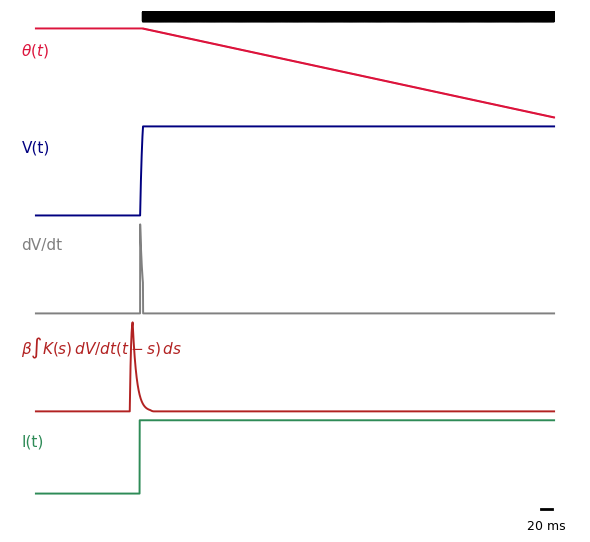

In [3]:
# STEPWISE INJECTED INPUT 

# Reset the NEST kernel to a completely clean state.
nest.ResetKernel()

# Only display errors from NEST (suppresses warnings and info messages).
nest.set_verbosity("M_ERROR")

# Configure parameters for the simulation kernel.
nest.SetKernelStatus({"resolution": 0.1, "local_num_threads": 1, "rng_seed": 12345})

# Load the compiled custom neuron module (.so library), available to nest.
nest.Install(module_name)
print("Is neuron loaded:", neuron_model_name in nest.node_models)  # nest.Models() is deprecated

# Creating instance of neuron, returning NodeCollection for the neuron.
# Specifying parameters we want to change from default.
neuron = nest.Create(
    neuron_model_name,
    params={
        "omega": 5.0,
        "alpha_1": -0.8,
        "alpha_2": 0.7,
    }
)

# Stepwise parameters for depolarising current amplitude start/stop.
dc_amplitude = 150  # pA (0.15 nA)
dc_start = 200.0
dc_stop = 1000.0

# Create a DC current generator.
# Between start and stop it injects a constant current.
dc = nest.Create("dc_generator", {
    "amplitude": dc_amplitude,
    "start": dc_start,
    "stop": dc_stop
})

# Connect DC to neuron.
nest.Connect(dc, neuron)

# Create a MULTIMETER to record membrane variables.
# (voltmeter can only ever record V_m — it does not support
#  arbitrary record_from lists, which is what threw the KeyError)
multimeter = nest.Create("multimeter", {
    "interval": 0.1,
    "record_from": ["V_m", "V_th_alpha_1", "V_th_alpha_2"]
})

# Attach the multimeter to the neuron.
nest.Connect(multimeter, neuron)

# This stores the times at which the neuron emits spikes.
spikedetector = nest.Create("spike_recorder")
nest.Connect(neuron, spikedetector)  # Attach the neuron to the spikedetector

nest.Simulate(1000.0)  # Run simulation for 1000ms

events = multimeter.get("events")  # Retrieve all recorded data.
t = events["times"]  # segmenting it out into different variables
V = events["V_m"]
spike_times = spikedetector.get("events")["times"]

params = nest.GetDefaults(neuron_model_name)  # Read the neuron's default parameters.
E_L = params["E_L"]      # leak reversal potential
omega = params["omega"]  # constant threshold offset used by the MAT model

# Reconstruct the injected current for plotting.
# This is a known step current, so we can build it directly
# from dc_start/dc_stop rather than interpolating.
I = np.zeros_like(t)
I[(t >= dc_start) & (t <= dc_stop)] = dc_amplitude

theta = E_L + omega + events["V_th_alpha_1"] + events["V_th_alpha_2"]  # total adaptive threshold

# Rate of change of voltage over time.
dVdt = np.gradient(V, t)

# Reconstruct the convolution term used by the MAT model.
dt = t[1] - t[0]
tau_k = 8.0  # time constant of the exponential kernel

kernel = np.exp(-np.arange(0, 40, dt) / tau_k)
kernel /= kernel.sum()  # normalize so total area equals one

conv = np.convolve(dVdt, kernel, mode="same")

# --------------------------------------------------------------
# Plot
# --------------------------------------------------------------
tp = TracePlotter(t, time_unit="ms")
for st in spike_times:
    tp.add_spike(st)

tp.add_trace("theta", theta, color="crimson", label=r"$\theta(t)$")
tp.add_trace("V", V, color="navy", label="V(t)")
tp.add_trace("dVdt", dVdt, color="gray", label="dV/dt")
tp.add_trace("conv", conv, color="firebrick", label=r"$\beta\int K(s)\,dV/dt(t-s)\,ds$")
tp.add_trace("I", I, color="seagreen", label="I(t)")

fig, axes = tp.plot(scalebar_ms=20)

Is neuron loaded: True
Ramp Simulation Completed.


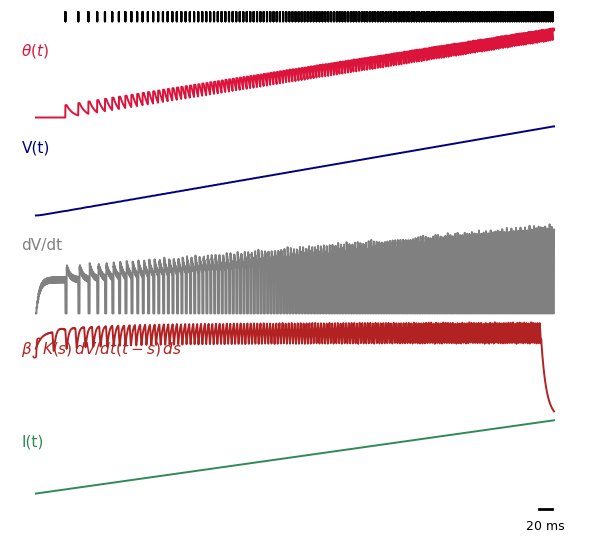

In [8]:
# RAMP INJECTED INPUT 

# Reset the NEST kernel to a completely clean state.
nest.ResetKernel()

# Only display errors from NEST (suppresses warnings and info messages).
nest.set_verbosity("M_ERROR")

# Configure parameters for the simulation kernel.
nest.SetKernelStatus({"resolution": 0.1, "local_num_threads": 1, "rng_seed": 12345})

# Load the compiled custom neuron module (.so library), available to nest.
# Must happen AFTER ResetKernel, since resetting unloads modules.
nest.Install(module_name)
print("Is neuron loaded:", neuron_model_name in nest.Models())  # debug

# --------------------------------------------------------------
# Build the network: neuron + recording devices.
# This was the piece missing before — nothing upstream of this
# actually created `neuron`, `voltmeter`, or `spikedetector`.
# --------------------------------------------------------------
# Creating instance of neuron, returning NodeColelction for the neuron 
# Specifying parameters we want to change from default. 
neuron = nest.Create(
    neuron_model_name,
    params={
        "omega": 5.0,
        "alpha_1": 15.0,
        "alpha_2": -0.05,
    }
)

# Create a voltmeter to record membrane variables.
voltmeter = nest.Create("voltmeter", {"interval": 0.1, "record_from": ["V_m", "V_th_alpha_1", "V_th_alpha_2"]})

# Record at the kernel resolution so voltage/threshold traces line up with I(t).
voltmeter.set({"interval": 0.1})

spikedetector = nest.Create("spike_recorder")

nest.Connect(voltmeter, neuron)
nest.Connect(neuron, spikedetector)

# --------------------------------------------------------------
# Ramp parameters
# --------------------------------------------------------------
dIdt = 2.5          # pA/ms — rate of current increase
I_start = 0.0       # pA — start at baseline, not hyperpolarized
ramp_duration = 800.0  # ms — total duration of the ramp experiment

# Set the neuron's initial injected current.
nest.SetStatus(neuron, {"I_e": I_start})

# Simulation update interval.
# Every step_ms we increase I_e and simulate forward.
step_ms = 1.0   # finer steps = smoother ramp; 10.0 gives a visible staircase

# Store current values for later plotting.
I_trace = []
time_trace = []

# --------------------------------------------------------------
# Run the ramp experiment.
#
# At every step:
#   1. Calculate the new current
#   2. Update the neuron
#   3. Simulate forward by step_ms
# --------------------------------------------------------------
for sim_time in np.arange(0, ramp_duration, step_ms):
    # Calculate linearly increasing current:
    #
    # I(t) = I_start + (dI/dt * time)
    #
    # Example:
    # t = 1000 ms
    # I = 0 + 2.5*1000
    # I = 2500 pA
    I_new = I_start + dIdt * sim_time

    # Apply the new current value to the neuron.
    nest.SetStatus(neuron, {"I_e": I_new})

    # Save current history for plotting later.
    I_trace.append(I_new)
    time_trace.append(sim_time)

    # Advance the simulation by step_ms.
    nest.Simulate(step_ms)

# --------------------------------------------------------------
# Retrieve recorded data.
# --------------------------------------------------------------
events = voltmeter.get("events")   # Retrieve all recorded voltage data.
t = events["times"]                # segmenting it out into different variables
V = events["V_m"]

spike_times = spikedetector.get("events")["times"]

params = nest.GetDefaults(neuron_model_name)  # Read the neuron's default parameters.
E_L = params["E_L"]        # leak reversal potential
omega = params["omega"]    # constant threshold offset used by the MAT model

# Reconstruct the injected current for plotting.
#
# The simulation updated I_e every step_ms,
# but the voltmeter recorded every 0.1 ms.
# np.interp maps the current history onto
# the recorded voltage time points.
I = np.interp(t, time_trace, I_trace)

theta = E_L + omega + events["V_th_alpha_1"] + events["V_th_alpha_2"]  # total adaptive threshold

print("Ramp Simulation Completed.")

# Rate of change of voltage over time.
dVdt = np.gradient(V, t)

# Reconstruct the convolution term used by the MAT model.
dt = t[1] - t[0]
tau_k = 8.0  # time constant of the exponential kernel

kernel = np.exp(-np.arange(0, 40, dt) / tau_k)
kernel /= kernel.sum()  # normalize so total area equals one

conv = np.convolve(dVdt, kernel, mode="same")

# --------------------------------------------------------------
# Plot
# --------------------------------------------------------------
tp = TracePlotter(t, time_unit="ms")
for st in spike_times:
    tp.add_spike(st)

tp.add_trace("theta", theta, color="crimson", label=r"$\theta(t)$")
tp.add_trace("V", V, color="navy", label="V(t)")
tp.add_trace("dVdt", dVdt, color="gray", label="dV/dt")
tp.add_trace("conv", conv, color="firebrick", label=r"$\beta\int K(s)\,dV/dt(t-s)\,ds$")
tp.add_trace("I", I, color="seagreen", label="I(t)")

fig, axes = tp.plot(scalebar_ms=20)